# Ouvidoria Inteligente · Entrega 3
## Dividindo as manifestações longas sem perder o sentido

As 5 manifestações com mais de 500 caracteres misturam vários assuntos num vetor só. Aqui cada uma é dividida com o `RecursiveCharacterTextSplitter` do LangChain em três configurações de `(chunk_size, chunk_overlap)`:

| Config | chunk_size | overlap | Ideia |
|---|---|---|---|
| A | 150 | 0 | pedaços pequenos, sem sobreposição |
| B | 150 | 50 | pedaços pequenos com ~1/3 de sobreposição |
| C | 300 | 60 | cerca de duas frases, com 20% de sobreposição |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nucleo_ouvidoria as nucleo

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 110)

base = nucleo.carregar_manifestacoes()
pos = {m: i for i, m in enumerate(base["id"])}
base.groupby("categoria_oficial").size().rename("manifestações").to_frame()

,manifestações
categoria_oficial,
educação,8
infraestrutura,9
meio ambiente,8
saúde,8
segurança,7


In [2]:
vetorizador = nucleo.Vetorizador()
longas = base.assign(tamanho=base["texto"].str.len()).nlargest(5, "tamanho").reset_index(drop=True)
CONFIGS = {"A (150, 0)": (150, 0), "B (150, 50)": (150, 50), "C (300, 60)": (300, 60)}

chunks = pd.DataFrame([
    {"config": cfg, "manifestacao": m.id, "categoria": m.categoria_oficial, "ordem": k, "texto": pedaco,
     "tamanho": len(pedaco)}
    for cfg, (tam, sob) in CONFIGS.items()
    for m in longas.itertuples()
    for k, pedaco in enumerate(nucleo.fatiar(m.texto, tam, sob), start=1)
])
chunks["vetor"] = list(vetorizador(chunks["texto"]))
display(longas[["id", "categoria_oficial", "tamanho"]])
chunks.groupby("config").agg(chunks=("texto", "size"), tamanho_medio=("tamanho", "mean"),
                             menor=("tamanho", "min"), maior=("tamanho", "max")).round(1)

,id,categoria_oficial,tamanho
0,M010,saúde,620
1,M040,educação,616
2,M033,meio ambiente,599
3,M024,segurança,592
4,M016,infraestrutura,582


,chunks,tamanho_medio,menor,maior
config,,,,
"A (150, 0)",32,93.2,17,149
"B (150, 50)",32,96.2,30,149
"C (300, 60)",14,214.3,93,293


### Parte A · A mesma denúncia (M016, ponte do Sítio Várzea) em cada configuração

In [3]:
(chunks[chunks.manifestacao == "M016"]
 .pivot_table(index="ordem", columns="config", values="texto", aggfunc="first")
 .fillna("")
 .style.set_properties(**{"white-space": "pre-wrap", "text-align": "left", "vertical-align": "top"}))

config,"A (150, 0)","B (150, 50)","C (300, 60)"
ordem,,,
1,Moro na comunidade do Sítio Várzea e a única ligação com a cidade é uma ponte de madeira sobre o riacho que está com várias tábuas podres e sem,Moro na comunidade do Sítio Várzea e a única ligação com a cidade é uma ponte de madeira sobre o riacho que está com várias tábuas podres e sem,"Moro na comunidade do Sítio Várzea e a única ligação com a cidade é uma ponte de madeira sobre o riacho que está com várias tábuas podres e sem proteção lateral. Quando chove, a estrada de terra que chega até a ponte vira lama e o ônibus escolar e o carro do lixo simplesmente param de passar."
2,proteção lateral.,o riacho que está com várias tábuas podres e sem proteção lateral.,"No mês passado uma moto caiu da ponte e o rapaz quebrou a perna. Os moradores já fizeram mutirão para trocar algumas tábuas, mas o problema é estrutural. Pedimos a construção de uma ponte de concreto e o cascalhamento da estrada antes do próximo inverno, porque a comunidade fica isolada."
3,"Quando chove, a estrada de terra que chega até a ponte vira lama e o ônibus escolar e o carro do lixo simplesmente param de passar.","Quando chove, a estrada de terra que chega até a ponte vira lama e o ônibus escolar e o carro do lixo simplesmente param de passar.",
4,No mês passado uma moto caiu da ponte e o rapaz quebrou a perna.,No mês passado uma moto caiu da ponte e o rapaz quebrou a perna.,
5,"Os moradores já fizeram mutirão para trocar algumas tábuas, mas o problema é estrutural.","Os moradores já fizeram mutirão para trocar algumas tábuas, mas o problema é estrutural.",
6,"Pedimos a construção de uma ponte de concreto e o cascalhamento da estrada antes do próximo inverno, porque a comunidade fica isolada.","Pedimos a construção de uma ponte de concreto e o cascalhamento da estrada antes do próximo inverno, porque a comunidade fica isolada.",


### Parte B · Coesão entre chunks consecutivos
Cosseno entre o chunk *k* e o chunk *k+1* de cada manifestação: quanto maior, mais os vizinhos se complementam.

In [4]:
coesao = pd.DataFrame([
    {"config": cfg, "manifestacao": mid, "cosseno": float(g.vetor.iloc[k] @ g.vetor.iloc[k + 1])}
    for (cfg, mid), g in chunks.sort_values("ordem").groupby(["config", "manifestacao"])
    for k in range(len(g) - 1)
])
tabela = coesao.pivot_table(index="manifestacao", columns="config", values="cosseno")
tabela.loc["MÉDIA"] = coesao.groupby("config")["cosseno"].mean()
tabela.round(3).style.background_gradient(cmap="Blues", axis=None)

config,"A (150, 0)","B (150, 50)","C (300, 60)"
manifestacao,,,
M010,0.244000,0.244000,0.363000
M016,0.237000,0.316000,0.644000
M024,0.130000,0.220000,0.459000
M033,0.256000,0.256000,0.393000
M040,0.275000,0.275000,0.448000
MÉDIA,0.225000,0.260000,0.441000


### Parte C · Os chunks preservam o sentido?
Dois testes: o cosseno de cada chunk com a manifestação inteira, e consultas curtas sobre detalhes que ficam no meio das denúncias (✓ = o melhor chunk é da manifestação certa).

In [5]:
inteiras = dict(zip(longas["id"], vetorizador(longas["texto"])))
chunks["cos_original"] = [float(v @ inteiras[m]) for v, m in zip(chunks.vetor, chunks.manifestacao)]
display(chunks.groupby("config")["cos_original"].agg(media="mean", minimo="min").round(3))

CONSULTAS = {"falta de insulina para diabético": "M010", "moto caiu da ponte de madeira": "M016",
             "câmeras e rondas na saída da escola": "M024", "peixes morrendo e pescadores sem sustento": "M033",
             "criança carregada no colo pela escada": "M040"}
linhas = []
for consulta, alvo in CONSULTAS.items():
    q = vetorizador.um(consulta)
    linha = {"consulta": consulta, "alvo": alvo}
    for cfg in CONFIGS:
        sub = chunks[chunks.config == cfg]
        s = np.vstack(sub.vetor) @ q
        melhor = sub.iloc[int(s.argmax())]
        linha[cfg] = f"{melhor.manifestacao} {s.max():.2f} {'✓' if melhor.manifestacao == alvo else '✗'}"
    s_inteiro = np.vstack(list(inteiras.values())) @ q
    linha["texto inteiro"] = f"{list(inteiras)[int(s_inteiro.argmax())]} {s_inteiro.max():.2f}"
    linhas.append(linha)
pd.DataFrame(linhas)

,media,minimo
config,,
"A (150, 0)",0.525,0.189
"B (150, 50)",0.537,0.189
"C (300, 60)",0.726,0.425


,consulta,alvo,"A (150, 0)","B (150, 50)","C (300, 60)",texto inteiro
0,falta de insulina para diabético,M010,M010 0.74 ✓,M010 0.74 ✓,M010 0.68 ✓,M010 0.69
1,moto caiu da ponte de madeira,M016,M016 0.78 ✓,M016 0.78 ✓,M016 0.66 ✓,M016 0.60
2,câmeras e rondas na saída da escola,M024,M024 0.61 ✓,M024 0.61 ✓,M024 0.61 ✓,M024 0.45
3,peixes morrendo e pescadores sem sustento,M033,M033 0.86 ✓,M033 0.86 ✓,M033 0.74 ✓,M033 0.42
4,criança carregada no colo pela escada,M040,M040 0.45 ✓,M040 0.45 ✓,M040 0.50 ✓,M040 0.52


### Parte D · Os chunks no plano (configuração B)
Cada cor é uma manifestação; o rótulo `16.3` quer dizer M016, chunk 3.

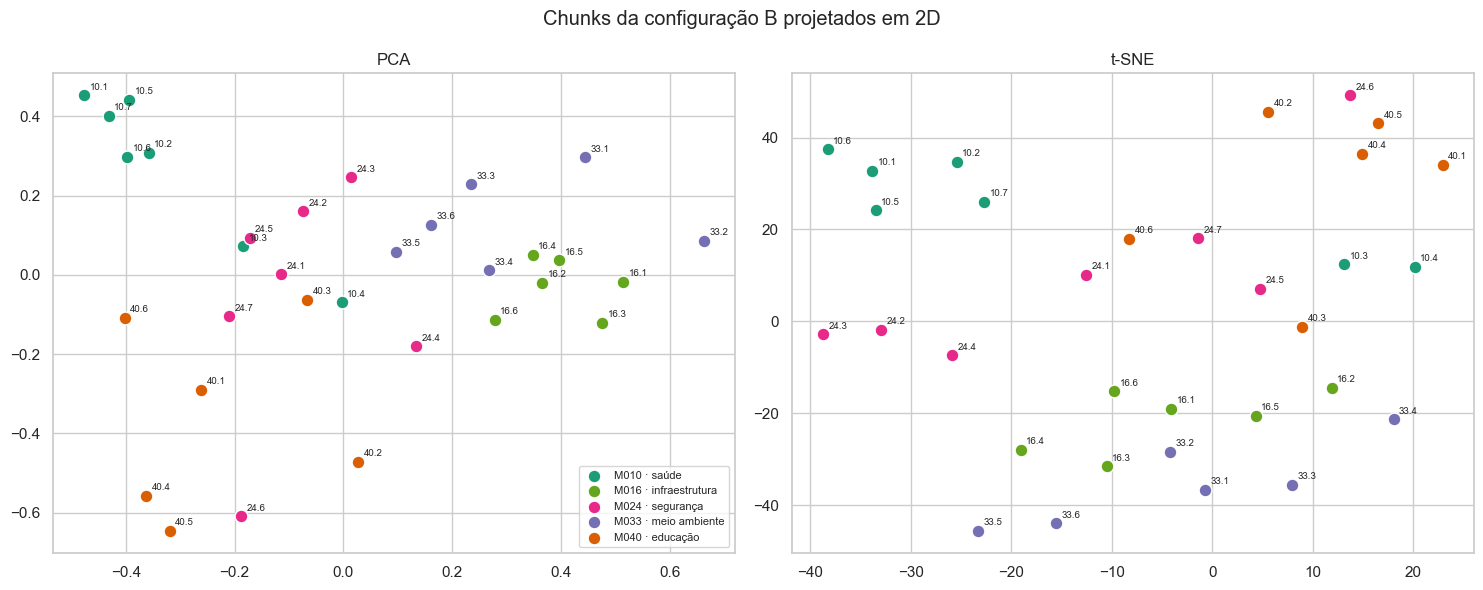

In [6]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

sub = chunks[chunks.config == "B (150, 50)"].reset_index(drop=True)
V = np.vstack(sub.vetor)
projecoes = {"PCA": PCA(n_components=2, random_state=42).fit_transform(V),
             "t-SNE": TSNE(n_components=2, perplexity=8, random_state=42).fit_transform(V)}
fig, eixos = plt.subplots(1, 2, figsize=(15, 6))
paleta = dict(zip(longas["id"], sns.color_palette("Dark2", 5)))
for ax, (nome, P) in zip(eixos, projecoes.items()):
    for mid, g in sub.groupby("manifestacao"):
        ax.scatter(P[g.index, 0], P[g.index, 1], s=85, color=paleta[mid], edgecolor="white",
                   label=f"{mid} · {g.categoria.iloc[0]}")
        for k in g.index:
            ax.annotate(f"{mid[-2:]}.{sub.ordem[k]}", P[k], fontsize=7, xytext=(4, 4), textcoords="offset points")
    ax.set_title(nome)
eixos[0].legend(fontsize=8, frameon=True)
plt.suptitle("Chunks da configuração B projetados em 2D"); plt.tight_layout(); plt.show()

In [7]:
def mesma_vs_diferente(cfg):
    g = chunks[chunks.config == cfg]
    M = np.vstack(g.vetor) @ np.vstack(g.vetor).T
    igual = g.manifestacao.to_numpy()[:, None] == g.manifestacao.to_numpy()[None, :]
    return {"mesma manifestação": M[igual & ~np.eye(len(g), dtype=bool)].mean(), "manifestações diferentes": M[~igual].mean()}

pd.DataFrame({cfg: mesma_vs_diferente(cfg) for cfg in CONFIGS}).T.round(3)

,mesma manifestação,manifestações diferentes
"A (150, 0)",0.240,0.113
"B (150, 50)",0.249,0.114
"C (300, 60)",0.413,0.194


## Respostas às perguntas da Entrega 3

**Como o overlap influencia a coesão semântica entre chunks consecutivos?**
O overlap aumentou a coesão média de 0,225 (A, sem overlap) para 0,260 (B, overlap 50) com o mesmo tamanho de chunk. O maior ganho foi em M016 (0,237 → 0,316) e M024 (0,130 → 0,220), justamente onde uma frase longa foi cortada no meio: em A, o chunk 2 da M016 ficou só com "proteção lateral."; em B ele virou "o riacho que está com várias tábuas podres e sem proteção lateral.", que carrega o sujeito da frase. Nas manifestações em que cada frase coube inteira num chunk (M010, M033, M040), A e B deram exatamente o mesmo resultado. Isso mostra como o `RecursiveCharacterTextSplitter` funciona: o overlap só repete pedaços **menores que chunk_overlap**, então, quando a quebra cai numa fronteira de frase de ~130 caracteres, não sobra nada para sobrepor. O overlap protege as fronteiras "ruins", no meio da frase, e não muda as boas.

**Qual configuração preserva melhor o sentido das denúncias?**
Depende do que se quer preservar:
- **C (300, 60)** preserva melhor a **denúncia como um todo**. Cada chunk tem cosseno médio de 0,726 com o texto original (contra 0,525 em A e 0,537 em B), a coesão entre chunks vizinhos é a maior (0,441), e cada chunk junta problema e pedido (ex.: M016 → "a moto caiu da ponte… pedimos ponte de concreto"). Com ~215 caracteres, também gera menos da metade dos chunks (14 contra 32).
- **B (150, 50)** é melhor para **achar um detalhe específico**. Nas consultas sobre um fato no meio da denúncia, os chunks pequenos têm scores mais altos ("peixes morrendo…": 0,86 em B × 0,74 em C × 0,42 no texto inteiro; "moto caiu da ponte": 0,78 × 0,66 × 0,60). Os três chunkings acertaram a manifestação certa nas 5 consultas.
- **A (150, 0)** é o pior: cria fragmentos sem sentido próprio ("proteção lateral.", 17 caracteres).

**Escolha:** para a ouvidoria, **C (300, 60)**, porque o objetivo é classificar e agrupar denúncias, e cada chunk precisa dizer "qual é o problema e onde". Se a prioridade fosse busca por detalhes (RAG sobre as manifestações), a B seria preferível. Em ambos os casos, o chunking resolve o problema original: sem chunking, a consulta "peixes morrendo e pescadores sem sustento" tem score 0,42 contra a própria M033, porque o detalhe se dilui no vetor do texto inteiro.

**Os chunks de uma mesma manifestação ficam próximos no espaço 2D?**
Em grande parte, sim. Numericamente, a similaridade média entre chunks da mesma manifestação é cerca de 2× maior que entre manifestações diferentes em todas as configurações (C: 0,413 × 0,194; B: 0,249 × 0,114). Nos gráficos (configuração B):
- **M010 (insulina)** forma o grupo mais compacto nas duas projeções. Só os chunks que narram as idas à farmácia, sem citar remédio ou doença, se afastam.
- **M016 (ponte) e M033 (rio/entulho)** ficam na mesma região e, no t-SNE, se misturam. As duas falam de rio, ponte, cheia e comunidade, e é o mesmo par que apareceu como falso positivo na Entrega 2.
- **M024 (drogas na praça ao lado da escola)** é a mais espalhada e encosta na **M040 (acessibilidade na escola)**: as duas falam de escola, alunos e pais.

Ou seja, os chunks se agrupam pelo **assunto de cada trecho**, não pela manifestação de origem. Quando uma denúncia toca em vários temas (segurança + escola), seus chunks se distribuem entre esses temas. Isso é bom para a triagem, porque cada trecho vai para perto dos problemas parecidos, mas mostra que é preciso guardar o `id` da manifestação como metadado de cada chunk para reconstruir a denúncia original.